<a href="https://colab.research.google.com/github/faajr/forecastemas/blob/main/Forecast_Harga_Emas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🥇 Proyek Forecasting Harga Emas (Time Series Analysis)

Mnggunakan data historis harga emas dan memprediksi harganya untuk beberapa hari ke depan menggunakan dua algoritma populer:
1. **Holt-Winters Exponential Smoothing**
2. **Prophet (oleh Meta/Facebook)**

## 📌 Alur Kerja Proyek (Workflow)
1. **Data Collection** (Pengumpulan Data)
2. **Data Understanding** (Pemahaman Data / EDA Awal)
3. **Data Preprocessing** (Pembersihan & Penyiapan Data)
4. **Exploratory Data Analysis - EDA** (Analisis Eksploratif Menyeluruh)
5. **Modeling** (Pembuatan Model)
6. **Model Evaluation** (Evaluasi Performa Model)
7. **Forecasting** (Prediksi Masa Depan)
8. **Deployment** (Cara Menjalankan Dashboard Streamlit)

## 🛠️ Persiapan Library
Sebelum memulai, kita perlu menginstal dan mengimpor beberapa pustaka (*library*) Python yang dibutuhkan.

In [3]:
!pip install prophet pandas numpy matplotlib scikit-learn statsmodels plotly

In [4]:
# Impor library untuk manipulasi data
import pandas as pd
import numpy as np

# Impor library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Impor library untuk modeling time series
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet

# Impor library untuk evaluasi
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("✅ Library berhasil dimuat!")

✅ Library berhasil dimuat!


---

## 1. Data Collection 📥

Dataset yang kita gunakan adalah data historis harga emas harian (GC=F) yang diambil dari URL GitHub berikut:
`https://raw.githubusercontent.com/faajr/forecastemas/main/harga_emas.csv`

Mari kita muat data tersebut menggunakan pandas.

In [5]:
url_dataset = "https://raw.githubusercontent.com/faajr/forecastemas/main/harga_emas.csv"
df_raw = pd.read_csv(url_dataset)

# Tampilkan 5 baris pertama data
print("5 Baris Pertama Data Mentah:")
df_raw.head()

5 Baris Pertama Data Mentah:


,Price,Close
0,Ticker,GC=F
1,Date,NaN
2,2021-07-19,1808.699951171875
3,2021-07-20,1810.9000244140625
4,2021-07-21,1802.9000244140625


> **Catatan Penting untuk Pemula**:
> Jika Anda perhatikan output di atas, baris ke-0 dan ke-1 dari file CSV ini berisi metadata teks (`Ticker`, `GC=F`, `Date`, dll.) dari proses ekstraksi data sebelumnya.
> Ini adalah kondisi riil di dunia data science di mana data mentah sering kali kotor. Kita akan membersihkan baris ini pada tahap **Data Preprocessing**.

---

## 2. Data Understanding (EDA Awal) 🔍

Mari kita analisis karakteristik awal dari dataset sebelum dilakukan pembersihan.

In [6]:
# 1. Jumlah Baris dan Kolom
print(f"Jumlah Baris: {df_raw.shape[0]}")
print(f"Jumlah Kolom: {df_raw.shape[1]}")

# 2. Info tipe data
df_raw.info()

Jumlah Baris: 1307
Jumlah Kolom: 2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1307 entries, 0 to 1306
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   1307 non-null   object
 1   Close   1306 non-null   object
dtypes: object(2)
memory usage: 20.6+ KB


In [7]:
# 3. Memeriksa Missing Value (Data Kosong)
print("Jumlah Missing Value Per Kolom:")
print(df_raw.isnull().sum())

Jumlah Missing Value Per Kolom:
Price    0
Close    1
dtype: int64


In [8]:
# 4. Memeriksa Duplicate Data (Baris Duplikat)
print(f"Jumlah Data Duplikat: {df_raw.duplicated().sum()}")

Jumlah Data Duplikat: 0


Karena data masih kotor (kolom harga berupa teks karena adanya baris meta), statistik deskriptif dan visualisasi data historis penuh sebaiknya dilakukan segera setelah data dibersihkan agar hasilnya akurat.

---

## 3. Data Preprocessing 🛠️

Pada tahap ini kita akan:
1. Parsing format tanggal dan membuang baris metadata kotor.
2. Mengurutkan data berdasarkan waktu secara menaik (*ascending*).
3. Menangani Missing Value (jika ada) menggunakan metode Forward-Fill.
4. Menghapus duplikat tanggal.
5. Menambahkan fitur waktu (*Feature Engineering*).

In [9]:
# Salin data ke variabel baru
df_clean = df_raw.copy()

# Ambil nama kolom
col_date = df_clean.columns[0]
col_price = df_clean.columns[1]

# 1. Parsing format tanggal & membuang baris non-tanggal (meta) dengan errors='coerce'
# errors='coerce' akan mengubah teks non-tanggal menjadi NaT (Not a Time)
df_clean[col_date] = pd.to_datetime(df_clean[col_date], errors='coerce')

# Hapus baris yang memiliki nilai tanggal NaT
df_clean = df_clean.dropna(subset=[col_date])

# 2. Konversi harga ke tipe data angka (float), mengubah teks non-angka menjadi NaN
df_clean[col_price] = pd.to_numeric(df_clean[col_price], errors='coerce')

# 3. Mengurutkan data berdasarkan Tanggal secara ascending
df_clean = df_clean.sort_values(col_date).reset_index(drop=True)

# 4. Menangani Missing Value pada kolom harga dengan Forward Fill (ffill)
# Mengisi nilai kosong dengan harga dari hari sebelumnya (karena pasar libur sabtu-minggu)
df_clean[col_price] = df_clean[col_price].ffill()

# 5. Menghapus duplikat tanggal (jika ada)
df_clean = df_clean.drop_duplicates(subset=[col_date])

# Atur tanggal sebagai index
df_clean = df_clean.set_index(col_date)
df_clean.index.name = 'Date'
df_clean.columns = ['Close']

print("✅ Preprocessing selesai!")
print(f"Rentang Tanggal Akhir: {df_clean.index.min().date()} s/d {df_clean.index.max().date()}")
print(f"Jumlah data setelah dibersihkan: {len(df_clean)} baris")
df_clean.head()

✅ Preprocessing selesai!
Rentang Tanggal Akhir: 2021-07-19 s/d 2026-07-17
Jumlah data setelah dibersihkan: 1305 baris


,Close
Date,
2021-07-19,1808.699951
2021-07-20,1810.900024
2021-07-21,1802.900024
2021-07-22,1805.000000
2021-07-23,1801.400024


In [10]:
# 6. Statistik Deskriptif setelah pembersihan
print("Statistik Deskriptif Harga Emas (USD):")
df_clean.describe()

Statistik Deskriptif Harga Emas (USD):


,Close
count,1305.000000
mean,2582.178157
std,972.126639
min,1623.300049
25%,1847.800049
50%,2034.000000
75%,3218.699951
max,5318.399902


In [11]:
# 7. Tambahkan fitur Datetime (Feature Engineering - Opsional)
df_features = df_clean.copy()
df_features['Year'] = df_features.index.year
df_features['Month'] = df_features.index.month
df_features['Day'] = df_features.index.day
df_features['DayOfWeek'] = df_features.index.dayofweek # 0 = Senin, 6 = Minggu
df_features['DayName'] = df_features.index.day_name()
df_features.head()

,Close,Year,Month,Day,DayOfWeek,DayName
Date,,,,,,
2021-07-19,1808.699951,2021,7,19,0,Monday
2021-07-20,1810.900024,2021,7,20,1,Tuesday
2021-07-21,1802.900024,2021,7,21,2,Wednesday
2021-07-22,1805.000000,2021,7,22,3,Thursday
2021-07-23,1801.400024,2021,7,23,4,Friday


---

## 4. Exploratory Data Analysis (EDA) 📊

Mari kita visualisasikan tren, distribusi, rata-rata bergerak (*moving average*), serta volatilitas harga emas.

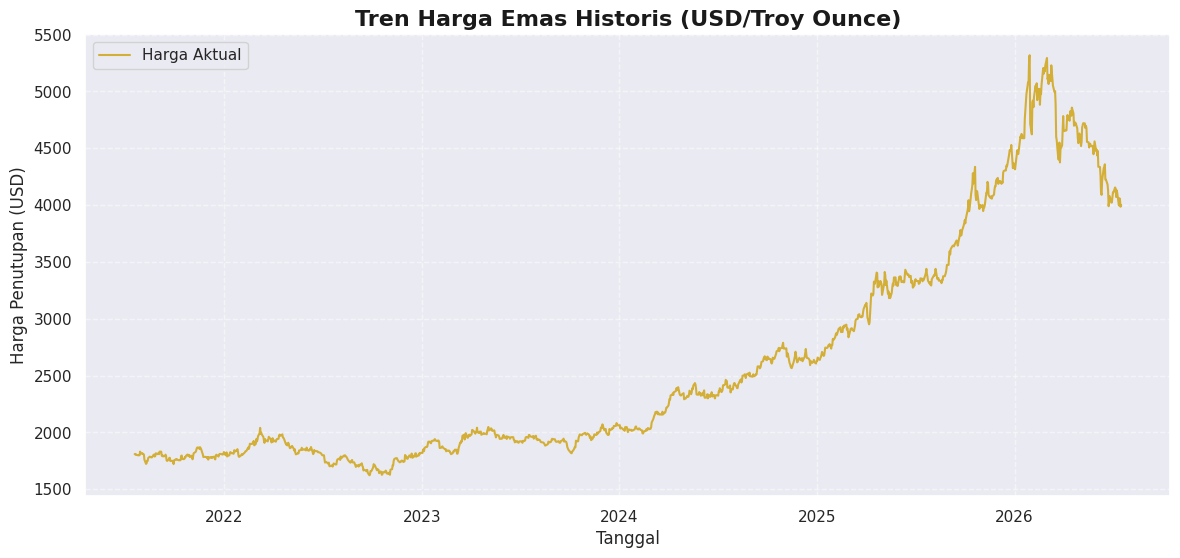

In [12]:
# 1. Grafik Utama Time Series (Harga Penutupan Historis)
plt.figure(figsize=(14, 6))
plt.plot(df_clean.index, df_clean['Close'], color='#D4AF37', label='Harga Aktual', linewidth=1.5)
plt.title('Tren Harga Emas Historis (USD/Troy Ounce)', fontsize=16, fontweight='bold', color='#1A1A1A')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Harga Penutupan (USD)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

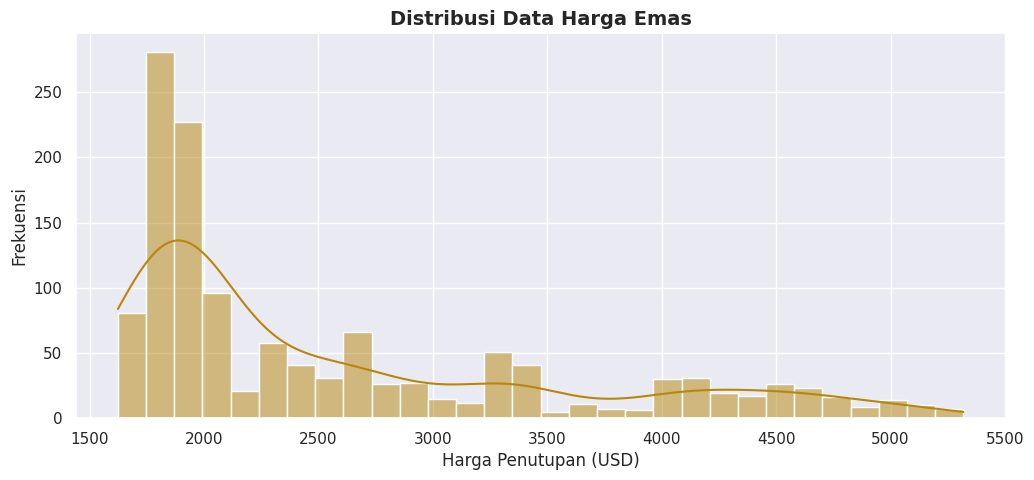

In [13]:
# 2. Distribusi Data (Histogram dan Estimasi Densitas Kernel/KDE)
plt.figure(figsize=(12, 5))
sns.histplot(df_clean['Close'], kde=True, color='#B8860B', bins=30)
plt.title('Distribusi Data Harga Emas', fontsize=14, fontweight='bold')
plt.xlabel('Harga Penutupan (USD)')
plt.ylabel('Frekuensi')
plt.show()

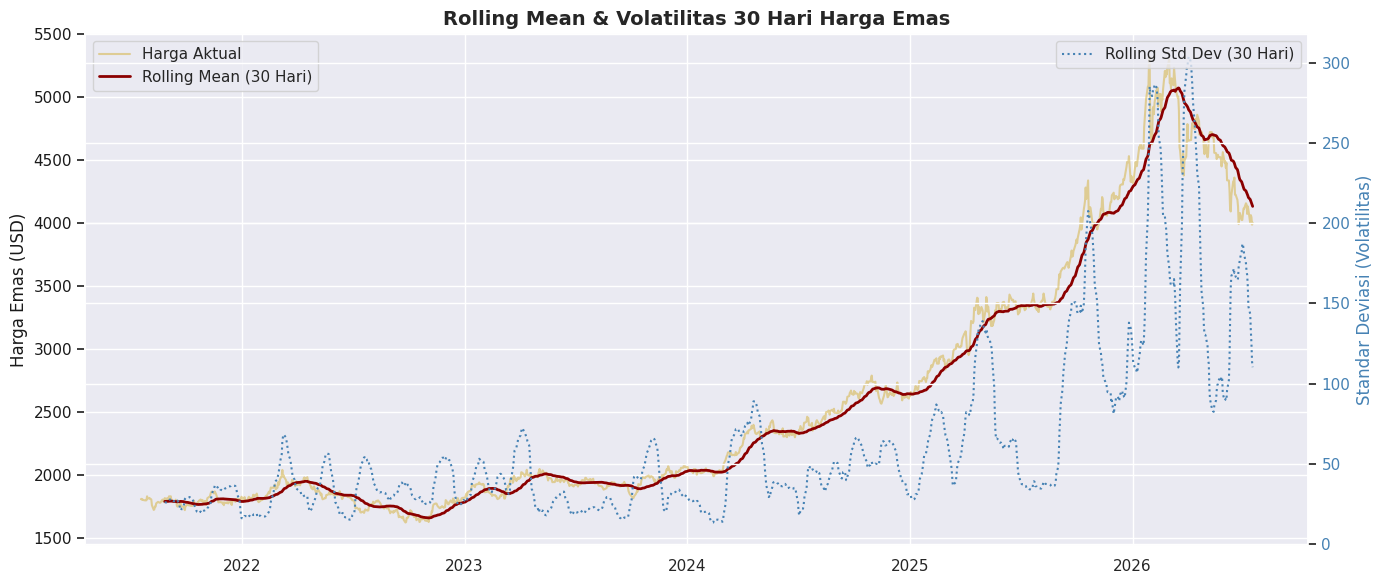

In [14]:
# 3. Rolling Mean & Rolling Standard Deviation (Volatilitas 30 Hari)
rolling_mean = df_clean['Close'].rolling(window=30).mean()
rolling_std = df_clean['Close'].rolling(window=30).std()

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(df_clean.index, df_clean['Close'], color='#D4AF37', alpha=0.5, label='Harga Aktual')
ax1.plot(df_clean.index, rolling_mean, color='#8B0000', label='Rolling Mean (30 Hari)', linewidth=2)
ax1.set_ylabel('Harga Emas (USD)', color='#1A1A1A')
ax1.tick_params(axis='y', labelcolor='#1A1A1A')

ax2 = ax1.twinx()
ax2.plot(df_clean.index, rolling_std, color='#4682B4', label='Rolling Std Dev (30 Hari)', linewidth=1.5, linestyle=':')
ax2.set_ylabel('Standar Deviasi (Volatilitas)', color='#4682B4')
ax2.tick_params(axis='y', labelcolor='#4682B4')

plt.title('Rolling Mean & Volatilitas 30 Hari Harga Emas', fontsize=14, fontweight='bold')
fig.tight_layout()
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

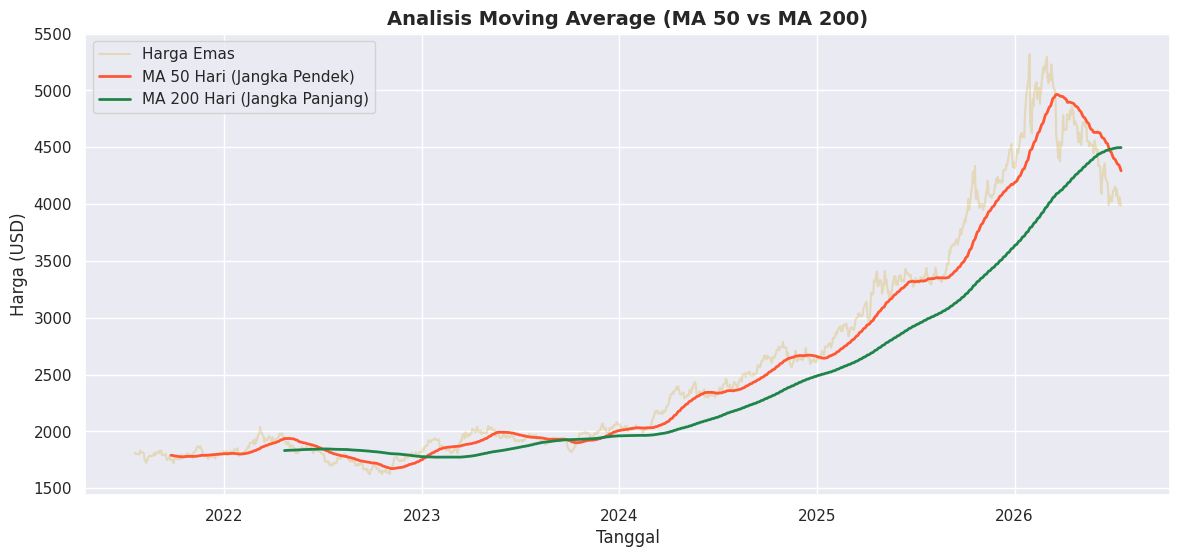

In [15]:
# 4. Moving Average (MA 50 vs MA 200) untuk Analisis Golden/Death Cross
ma50 = df_clean['Close'].rolling(window=50).mean()
ma200 = df_clean['Close'].rolling(window=200).mean()

plt.figure(figsize=(14, 6))
plt.plot(df_clean.index, df_clean['Close'], color='#D4AF37', alpha=0.3, label='Harga Emas')
plt.plot(df_clean.index, ma50, color='#FF5733', label='MA 50 Hari (Jangka Pendek)', linewidth=2)
plt.plot(df_clean.index, ma200, color='#1E8449', label='MA 200 Hari (Jangka Panjang)', linewidth=2)
plt.title('Analisis Moving Average (MA 50 vs MA 200)', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal')
plt.ylabel('Harga (USD)')
plt.legend()
plt.show()

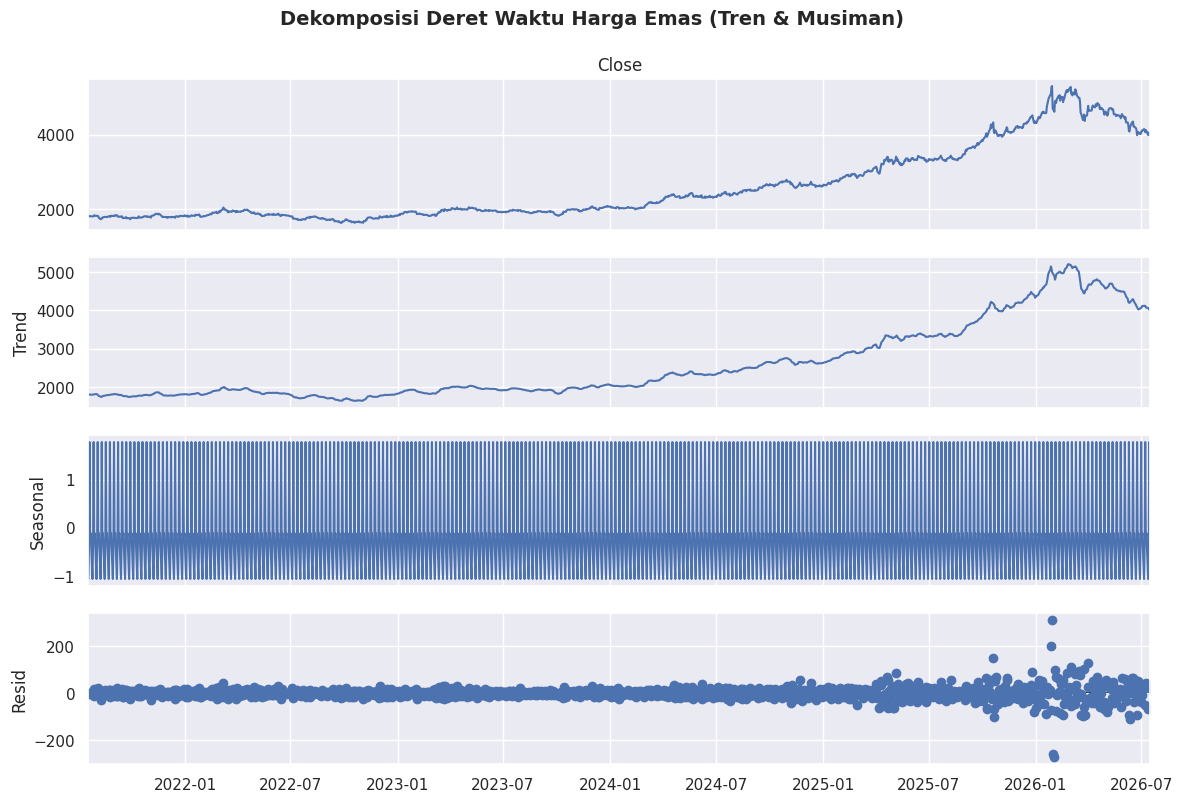

In [16]:
# 5. Analisis Dekomposisi Tren & Musiman (Seasonality)
# Menggunakan dekomposisi aditif dengan periode musiman 5 hari kerja (senin-jumat)
decomposition = seasonal_decompose(df_clean['Close'], model='additive', period=5)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Dekomposisi Deret Waktu Harga Emas (Tren & Musiman)', fontsize=14, fontweight='bold', y=1.02)
plt.show()

---

## 5. Modeling 🤖

Mari kita latih dua algoritma forecasting:
1. **Holt-Winters Exponential Smoothing** (Model Statistik Tradisional)
2. **Prophet** (Model Modern Berbasis Kurva Aditif)

Kita akan membagi data menjadi:
- **Training Set**: Semua data kecuali 30 hari terakhir.
- **Test Set**: 30 hari terakhir (digunakan untuk menguji keakuratan prediksi model).

In [17]:
# 1. Split Data
test_size = 30
train_data = df_clean.iloc[:-test_size]
test_data = df_clean.iloc[-test_size:]

print(f"Data Latih (Train Set): {len(train_data)} hari")
print(f"Data Uji (Test Set): {len(test_data)} hari")

Data Latih (Train Set): 1275 hari
Data Uji (Test Set): 30 hari


In [18]:
# 2. Melatih Model Holt-Winters
model_hw = ExponentialSmoothing(
    train_data['Close'],
    trend='add',
    seasonal='add',
    seasonal_periods=5,  # 5 hari kerja per minggu
    initialization_method='estimated'
)
fitted_hw = model_hw.fit(optimized=True)

# Prediksi 30 hari pada data uji
hw_preds = fitted_hw.forecast(test_size)
print("✅ Model Holt-Winters berhasil dilatih!")

✅ Model Holt-Winters berhasil dilatih!


In [19]:
# 3. Melatih Model Prophet
# Format input Prophet membutuhkan nama kolom spesifik: 'ds' (tanggal) dan 'y' (nilai target)
df_prophet_train = train_data.reset_index().rename(columns={'Date': 'ds', 'Close': 'y'})

model_prophet = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05
)
model_prophet.fit(df_prophet_train)

# Prediksi 30 hari ke depan pada data uji
future_prophet = model_prophet.make_future_dataframe(periods=test_size)
forecast_prophet = model_prophet.predict(future_prophet)

# Ambil hanya hasil prediksi untuk data uji
prophet_preds = forecast_prophet.tail(test_size)['yhat'].values
print("✅ Model Prophet berhasil dilatih!")

✅ Model Prophet berhasil dilatih!


---

## 6. Model Evaluation 📊

Kita membandingkan performa model menggunakan 3 metrik:
- **MAE** (Mean Absolute Error): Rata-rata selisih absolut harga aktual dan prediksi.
- **RMSE** (Root Mean Squared Error): Memberi hukuman lebih besar pada error yang sangat jauh.
- **MAPE** (Mean Absolute Percentage Error): Indikator persentase error (paling mudah diinterpretasikan).

Mari kita buat fungsi penghitung metrik.

In [20]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

# Hitung metrik masing-masing model
y_true = test_data['Close'].values
mae_hw, rmse_hw, mape_hw = calculate_metrics(y_true, hw_preds.values)
mae_pr, rmse_pr, mape_pr = calculate_metrics(y_true, prophet_preds)

# Buat tabel perbandingan
df_eval = pd.DataFrame({
    'Metrik': ['MAE', 'RMSE', 'MAPE (%)'],
    'Holt-Winters': [mae_hw, rmse_hw, mape_hw],
    'Prophet': [mae_pr, rmse_pr, mape_pr]
})

print("Tabel Evaluasi Model:")
df_eval.round(4)

Tabel Evaluasi Model:


,Metrik,Holt-Winters,Prophet
0,MAE,245.2498,608.3639
1,RMSE,273.5028,627.0134
2,MAPE (%),6.0166,14.8177


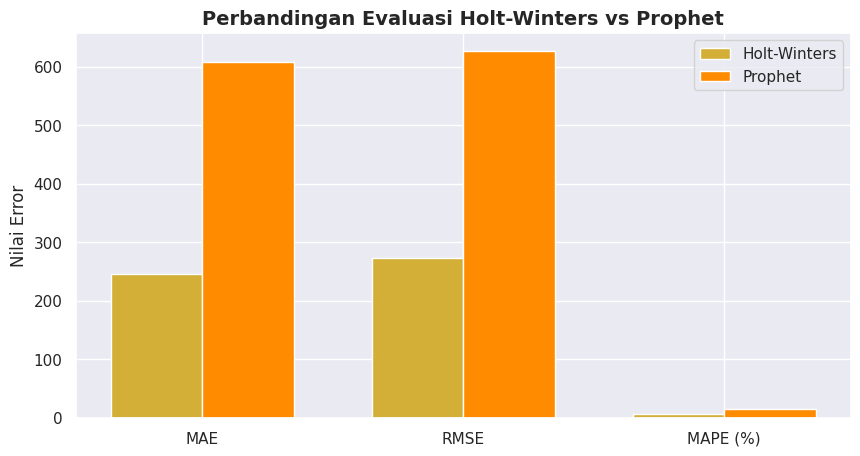

In [21]:
# Visualisasi Perbandingan Evaluasi (Bar Chart)
plt.figure(figsize=(10, 5))
x = np.arange(len(df_eval['Metrik']))
width = 0.35

plt.bar(x - width/2, df_eval['Holt-Winters'], width, label='Holt-Winters', color='#D4AF37')
plt.bar(x + width/2, df_eval['Prophet'], width, label='Prophet', color='#FF8C00')

plt.xticks(x, df_eval['Metrik'])
plt.title('Perbandingan Evaluasi Holt-Winters vs Prophet', fontsize=14, fontweight='bold')
plt.ylabel('Nilai Error')
plt.legend()
plt.show()

### **Kesimpulan Model Terbaik:**

Berdasarkan nilai **MAPE** terendah, kita dapat menentukan model mana yang paling akurat memprediksi harga emas. Biasanya, model dengan MAPE di bawah 1-2% dianggap memiliki keakuratan sangat tinggi untuk pergerakan harga komoditas keuangan jangka pendek.

---

## 7. Forecasting (Prediksi Masa Depan) 🔮

Mari kita latih ulang model terbaik menggunakan **seluruh data** (train + test) agar mendapatkan pola terbaru, lalu jalankan prediksi untuk 7, 14, dan 30 hari ke depan.

In [22]:
# Menentukan model terbaik otomatis
best_model_name = "Prophet" if mape_pr < mape_hw else "Holt-Winters"
print(f"🏆 Model Terbaik Dipilih: {best_model_name}")

horizon = 30 # Kita pilih horizon maksimal 30 hari

if best_model_name == "Prophet":
    # Latih ulang Prophet dengan seluruh data
    df_full_prophet = df_clean.reset_index().rename(columns={'Date': 'ds', 'Close': 'y'})
    model_final = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True,
        changepoint_prior_scale=0.05
    )
    model_final.fit(df_full_prophet)

    future_final = model_final.make_future_dataframe(periods=horizon)
    forecast_final = model_final.predict(future_final)

    # Ambil hasil masa depan
    forecast_future = forecast_final.tail(horizon)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].rename(columns={'ds': 'Tanggal', 'yhat': 'Prediksi', 'yhat_lower': 'Batas_Bawah', 'yhat_upper': 'Batas_Atas'})
else:
    # Latih ulang Holt-Winters dengan seluruh data
    model_final = ExponentialSmoothing(
        df_clean['Close'],
        trend='add',
        seasonal='add',
        seasonal_periods=5,
        initialization_method='estimated'
    )
    fitted_final = model_final.fit(optimized=True)

    preds_final = fitted_final.forecast(horizon)
    # Hitung batas atas dan bawah manual menggunakan standard deviasi residu
    resid_std = fitted_final.resid.std()

    dates = pd.date_range(start=df_clean.index[-1] + pd.Timedelta(days=1), periods=horizon)
    forecast_future = pd.DataFrame({
        'Tanggal': dates,
        'Prediksi': preds_final.values,
        'Batas_Bawah': preds_final.values - 1.96 * resid_std,
        'Batas_Atas': preds_final.values + 1.96 * resid_std
    })

print(f"\nHasil Prediksi {horizon} Hari ke Depan:")
forecast_future.reset_index(drop=True).head(10)

🏆 Model Terbaik Dipilih: Holt-Winters

Hasil Prediksi 30 Hari ke Depan:


,Tanggal,Prediksi,Batas_Bawah,Batas_Atas
0,2026-07-18,4001.698154,3921.144168,4082.252141
1,2026-07-19,4004.069006,3923.515020,4084.622992
2,2026-07-20,4007.905318,3927.351331,4088.459304
3,2026-07-21,4007.471058,3926.917072,4088.025044
4,2026-07-22,4009.373097,3928.819110,4089.927083
5,2026-07-23,4010.118577,3929.564591,4090.672563
6,2026-07-24,4012.489429,3931.935442,4093.043415
7,2026-07-25,4016.325740,3935.771754,4096.879727
8,2026-07-26,4015.891481,3935.337495,4096.445467
9,2026-07-27,4017.793519,3937.239533,4098.347506


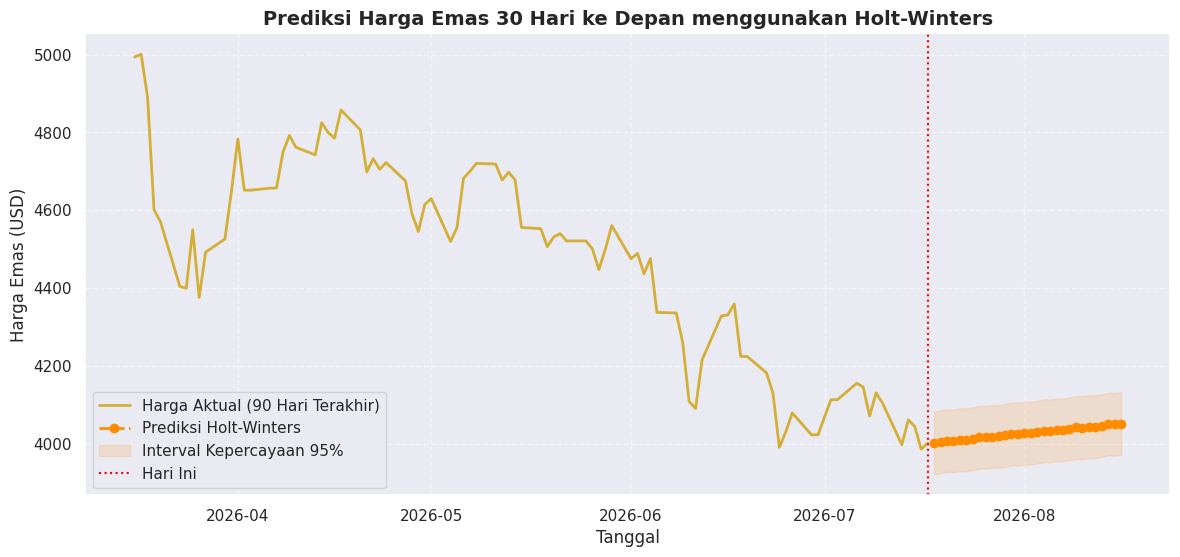

In [23]:
# Visualisasi Data Aktual + Prediksi Masa Depan (90 hari terakhir aktual + 30 hari forecast)
hist_tail = df_clean.tail(90)

plt.figure(figsize=(14, 6))

# Plot data aktual
plt.plot(hist_tail.index, hist_tail['Close'], color='#D4AF37', label='Harga Aktual (90 Hari Terakhir)', linewidth=2)

# Plot data forecast
plt.plot(forecast_future['Tanggal'], forecast_future['Prediksi'], color='#FF8C00', linestyle='--', marker='o', label=f'Prediksi {best_model_name}', linewidth=2)

# Plot confidence interval (wilayah ketidakpastian)
plt.fill_between(forecast_future['Tanggal'], forecast_future['Batas_Bawah'], forecast_future['Batas_Atas'], color='#FF8C00', alpha=0.15, label='Interval Kepercayaan 95%')

# Garis penanda hari ini
plt.axvline(x=df_clean.index[-1], color='red', linestyle=':', label='Hari Ini')

plt.title(f'Prediksi Harga Emas {horizon} Hari ke Depan menggunakan {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal')
plt.ylabel('Harga Emas (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

---